In [7]:
#!pip install torch

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
from pathlib import Path
import shutil
import random
import torch
from torch.utils.data import Dataset

In [8]:
# Copy dataset into folder
# db
# FVD - 1
# FV - 2
# MMC - 3

current_dir = os.getcwd()

folders_to_rename = {
    'Finger_Vein_Database': '1',
    'FV_USM': '2', 
    'MMCBNU_6000': '3'
}

path = './db'

for old_name, new_name in folders_to_rename.items():
    old_path = os.path.join(path, old_name)
    new_path = os.path.join(path, new_name)
    
    if os.path.exists(old_path) and os.path.isdir(old_path):
        os.rename(old_path, new_path)

print('Done')

Done


In [2]:
current_dir = os.getcwd()
path = './db'

# Create the db directory if it doesn't exist
if not os.path.exists(path):
    os.makedirs(path)

# Create 3 new folders with _label suffix
for i in range(1, 4):
    folder_name = f"{i}_label"
    folder_path = os.path.join(path, folder_name)
    
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)

print('Done')

Done


In [5]:
# Copy the masky_ into the curent director
current_dir = os.getcwd()

folders_to_rename = {
    'masky_prst_FVD': '1_mask',
    'masky_prst_fv': '2_mask', 
    'masky_prst_mmn': '3_mask',
    'masky_FVD': '1_image',
    'masky_fv': '2_image', 
    'masky_mmn': '3_image'
}

path = './db'

for old_name, new_name in folders_to_rename.items():
    old_path = os.path.join(path, old_name)
    new_path = os.path.join(path, new_name)
    
    if os.path.exists(old_path) and os.path.isdir(old_path):
        os.rename(old_path, new_path)

print('Done')

Done


In [6]:
# 1_label / 1_image a 1_mask
current_dir = os.getcwd()

# From 1 to 3
for i in range(1, 4):
    label_path = f'./db/{i}_label'
    image_folder = f'{i}_image'
    mask_folder = f'{i}_mask'
    
    image_src = os.path.join('./db', image_folder)
    mask_src = os.path.join('./db', mask_folder)
    
    # Check if source folders exist
    if os.path.exists(image_src) and os.path.isdir(image_src):
        image_dst = os.path.join(label_path, image_folder)
        shutil.move(image_src, image_dst)
    else:
        print(f"Source folder '{image_src}' not found")
    
    if os.path.exists(mask_src) and os.path.isdir(mask_src):
        mask_dst = os.path.join(label_path, mask_folder)
        shutil.move(mask_src, mask_dst)
    else:
        print(f"Source folder '{mask_src}' not found")

print('Done')

Done


In [11]:
# TODO: Remove images from {i}_label/{i}_image in {i} !!
# Remove that with mask in the unsupervised part!!
current_dir = os.getcwd()

path = './db'

for i in range(1, 4):
    image_folder = os.path.join(path, f'{i}_label', f'{i}_image')
    label_folder = os.path.join(path, f'{i}')
    
    # Check if both folders exist
    if os.path.exists(image_folder) and os.path.isdir(image_folder) and os.path.exists(label_folder):
        # Get list of files in the image folder
        image_files = set(os.listdir(image_folder))
        
        # Get list of files in the label folder
        label_files = os.listdir(label_folder)
        
        # Count removed files
        removed_count = 0
        
        # Remove files from label folder that exist in image folder
        for filename in label_files:
            if filename in image_files:
                file_path = os.path.join(label_folder, filename)
                if os.path.isfile(file_path):
                    os.remove(file_path)
                    removed_count += 1
        
    else:
        print(f"Folders not found for {i}")

print('Done')

Done


In [5]:
# Define paths
unlabel_path = "./db/unlabel"
test_path = "./db/test"

# Get all image files from unlabel folder
image_files = []
for f in os.listdir(unlabel_path):
    if os.path.isfile(os.path.join(unlabel_path, f)):
        image_files.append(f)
            
print(f"Found {len(image_files)} images in unlabel folder")

# Randomly select 1,660 images
random.seed(42)  # For reproducibility, remove this line if you want different random selection each time
selected_images = random.sample(image_files, 1660)

print(f"Moving {len(selected_images)} images to test folder...")

# Move selected images to test folder
for image in selected_images:
    src_path = os.path.join(unlabel_path, image)
    dst_path = os.path.join(test_path, image)
    shutil.move(src_path, dst_path)

print("Done! Moved 1,660 images to test folder")

Done! Moved 1,660 images to test folder


In [2]:
# TUTO OD TOHOTO ZACAT UZ !!!!!
class VeinDatasetCV(Dataset):
    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.filenames = [
            f for f in os.listdir(image_dir)
            if os.path.exists(os.path.join(mask_dir, f))
        ]

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        img_path = os.path.join(self.image_dir, fname)
        mask_path = os.path.join(self.mask_dir, fname)

        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        image = image.astype(np.float32) / 255.0
        mask = mask.astype(np.float32) / 255.0

        image = np.expand_dims(image, axis=0)
        mask = np.expand_dims(mask, axis=0)

        return torch.from_numpy(image), torch.from_numpy(mask)

In [3]:
class UnlabeledVeinDataset(Dataset):
    def __init__(self, image_dir):
        self.image_dir = image_dir
        self.filenames = os.listdir(image_dir)

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        img_path = os.path.join(self.image_dir, fname)

        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        image = image.astype(np.float32) / 255.0
        image = np.expand_dims(image, axis=0)

        return torch.from_numpy(image), fname

In [6]:
from torch.utils.data import random_split, DataLoader

# Paths
label_img_dir = "./db/label/image"
label_mask_dir = "./db/label/mask"
unlabel_img_dir = "./db/unlabel"
test_img_dir = "./db/test"

# --- Labeled dataset (supervised phase) ---
labeled_dataset = VeinDatasetCV(label_img_dir, label_mask_dir)

train_size = int(0.8 * len(labeled_dataset))
val_size = len(labeled_dataset) - train_size
train_ds, val_ds = random_split(labeled_dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False)

# --- Unlabeled dataset (semi-supervised phase) ---
unlabeled_dataset = UnlabeledVeinDataset(unlabel_img_dir)
unlabeled_loader  = DataLoader(unlabeled_dataset, batch_size=8, shuffle=True)

# --- Test dataset (final evaluation) ---
test_dataset = UnlabeledVeinDataset(test_img_dir)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False)


In [7]:
for imgs, masks in train_loader:
    print("Train batch:")
    print("  Images:", imgs.shape)
    print("  Masks:", masks.shape)
    print("  Value range:", imgs.min().item(), "→", imgs.max().item())
    break

for imgs, masks in val_loader:
    print("Val batch:")
    print("  Images:", imgs.shape)
    print("  Masks:", masks.shape)
    break

for imgs, names in unlabeled_loader:
    print("Unlabeled batch:")
    print("  Images:", imgs.shape)
    print("  Filenames:", names[:3])
    break


Train batch:
  Images: torch.Size([8, 1, 240, 320])
  Masks: torch.Size([8, 1, 240, 320])
  Value range: 0.0 → 0.9411764740943909
Val batch:
  Images: torch.Size([8, 1, 240, 320])
  Masks: torch.Size([8, 1, 240, 320])
Unlabeled batch:
  Images: torch.Size([8, 1, 240, 320])
  Filenames: ('084_r_ring_3.jpg', '009_r_26.jpg', '017_07.jpg')


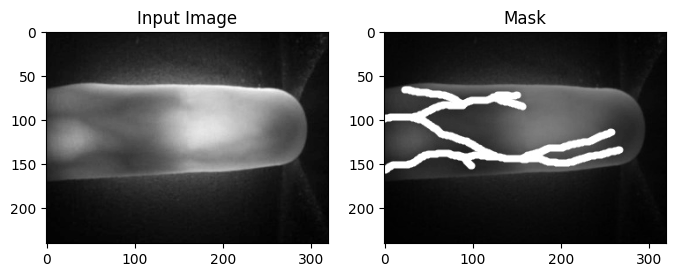

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Take one example from your labeled dataset
img, mask = labeled_dataset[0]

# Convert to numpy arrays for display
img_np = img.squeeze().numpy()
mask_np = mask.squeeze().numpy()

# Show side by side
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title("Input Image")
plt.imshow(img_np, cmap='gray')

plt.subplot(1,2,2)
plt.title("Mask")
plt.imshow(mask_np, cmap='gray')
plt.show()


In [9]:
print("Labeled total:", len(labeled_dataset))
print("  Train:", len(train_ds))
print("  Val:", len(val_ds))
print("Unlabeled total:", len(unlabeled_dataset))
print("Test total:", len(test_dataset))


Labeled total: 60
  Train: 48
  Val: 12
Unlabeled total: 14000
Test total: 1660


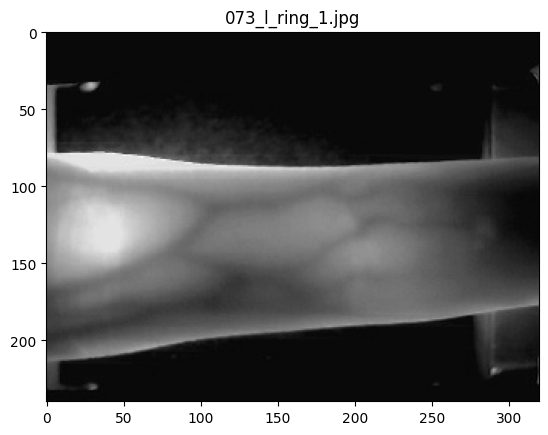

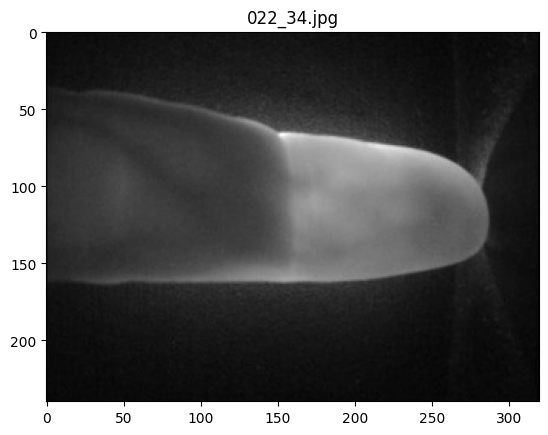

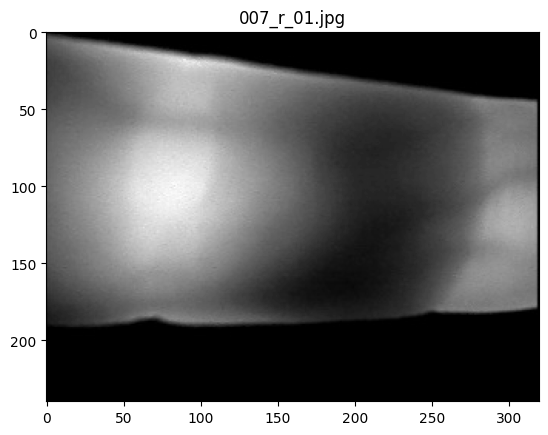

In [10]:
imgs, fnames = next(iter(unlabeled_loader))
for i in range(3):
    plt.imshow(imgs[i].squeeze().numpy(), cmap='gray')
    plt.title(fnames[i])
    plt.show()
